In [45]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

import numpy as np
import pandas as pd

import torch

from transformers import (
    AutoImageProcessor,
    AutoModel
)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

import umap
import hdbscan

import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
DATASET_ROOT = Path("./Few-Short-Pets/Sythentic-Data/")

REAL_DIR = DATASET_ROOT / "Real-Img"
FAKE_DIR = DATASET_ROOT / "Fake-Img"

OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

KMEANS_CLUSTER = 37

# Load DINOv2

In [12]:
print("Loading DINOv2...")

processor = AutoImageProcessor.from_pretrained(
    "facebook/dinov2-base"
)

model = AutoModel.from_pretrained(
    "facebook/dinov2-base"
)

model.to(DEVICE)
model.eval()

Loading DINOv2...


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 5865.87it/s]


Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((768,),

# Feature Extractor

In [ ]:
def extract_feature(image_path):
    image = Image.open(image_path).convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(DEVICE)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model(**inputs)

        feature = (
            outputs.last_hidden_state[:, 0, :]
            .squeeze()
            .cpu()
            .numpy()
        )

    return feature

# Load Data

In [18]:
features = []
domains = []
classes = []
paths = []

# Real Data

In [21]:
print("Loading REAL images...")

for class_dir in tqdm(sorted(REAL_DIR.iterdir())):
    if not class_dir.is_dir():
        continue

    for img_path in class_dir.glob("*"):
        try:
            feature = extract_feature(img_path)

            features.append(feature)
            domains.append("Real")
            classes.append(class_dir.name)
            paths.append(str(img_path))

        except Exception as e:
            print(img_path, e)

Loading REAL images...


100%|██████████| 37/37 [00:21<00:00,  1.72it/s]


# Fake Data

In [22]:
print("Loading FAKE images...")

for class_dir in tqdm(sorted(FAKE_DIR.iterdir())):
    if not class_dir.is_dir():
        continue

    for img_path in class_dir.glob("*"):
        try:
            feature = extract_feature(img_path)

            features.append(feature)
            domains.append("Fake")
            classes.append(class_dir.name)
            paths.append(str(img_path))

        except Exception as e:
            print(img_path, e)

Loading FAKE images...


100%|██████████| 37/37 [04:56<00:00,  8.00s/it]


In [23]:
X = np.array(features)

print("Feature Shape:", X.shape)

Feature Shape: (5550, 768)


In [24]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# UMAP

In [25]:
print("Running UMAP...")

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embedding = umap_model.fit_transform(X_scaled)

Running UMAP...


# KMeans

In [28]:
print("Running KMeans...")

kmeans = KMeans(
    n_clusters=KMEANS_CLUSTER,
    random_state=42,
    n_init="auto"
)

kmeans_labels = kmeans.fit_predict(X_scaled)

Running KMeans...


# HDBSCAN

In [27]:
print("Running HDBSCAN...")

hdb = hdbscan.HDBSCAN(
    min_cluster_size=10,
    metric="euclidean"
)

hdb_labels = hdb.fit_predict(X_scaled)

Running HDBSCAN...


# Dataframe

In [31]:
df = pd.DataFrame({
    "x": embedding[:,0],
    "y": embedding[:,1],
    "domain": domains,
    "class": classes,
    "kmeans": kmeans_labels,
    "hdbscan": hdb_labels
})

# Visualization

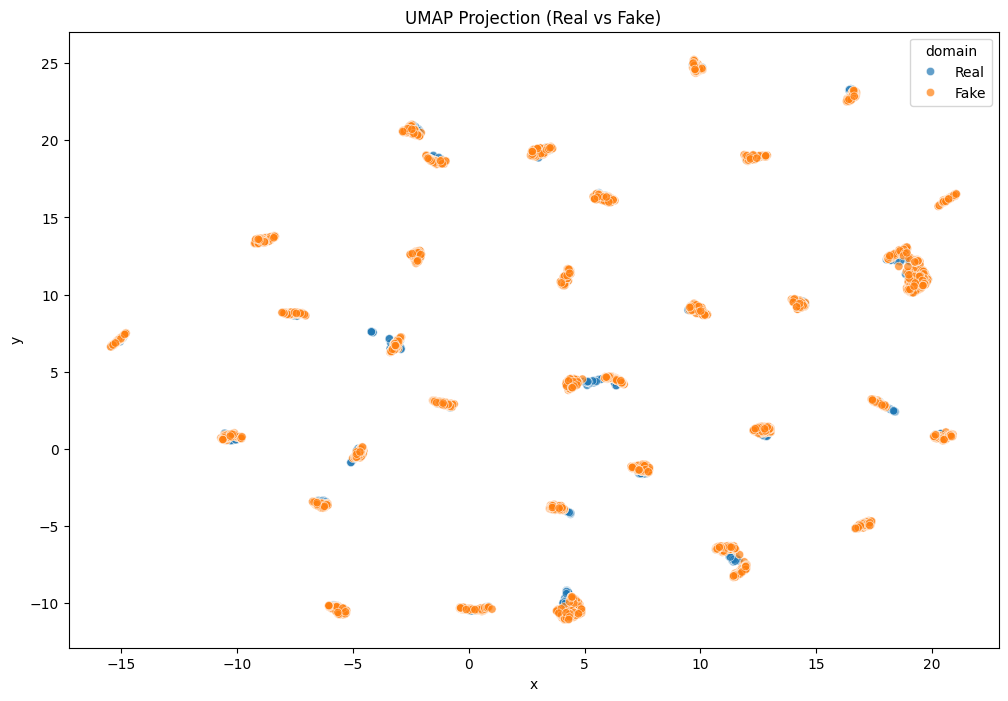

In [40]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="domain",
    alpha=0.7
)

plt.title(
    "UMAP Projection (Real vs Fake)"
)

plt.savefig(
    OUTPUT_DIR / "01_real_vs_fake.png",
    dpi=300,
    bbox_inches="tight"
)

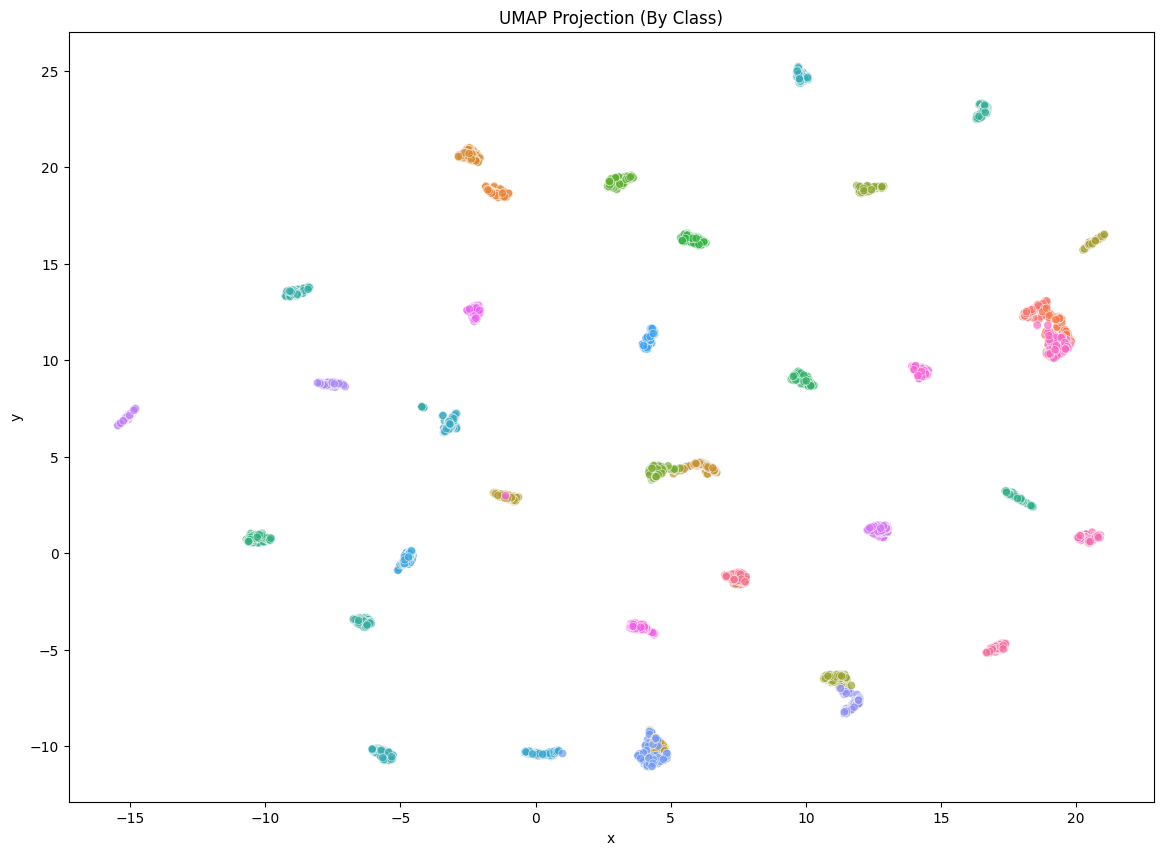

In [41]:
plt.figure(figsize=(14,10))

sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="class",
    alpha=0.7,
    legend=False
)

plt.title(
    "UMAP Projection (By Class)"
)

plt.savefig(
    OUTPUT_DIR / "02_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

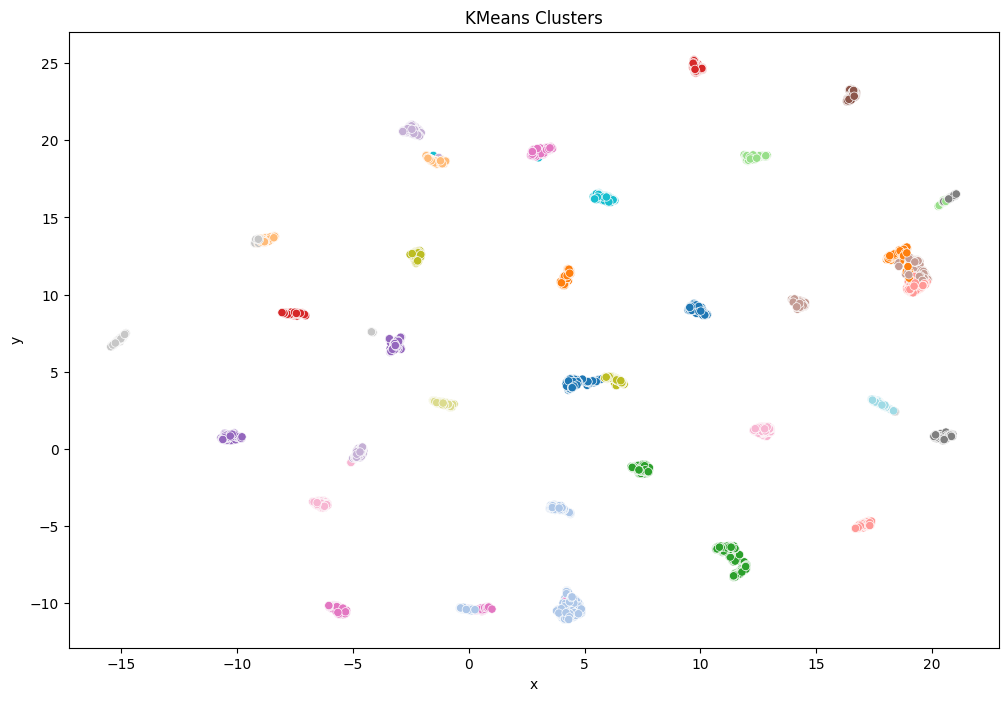

In [42]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="kmeans",
    palette="tab20",
    legend=False
)

plt.title(
    "KMeans Clusters"
)

plt.savefig(
    OUTPUT_DIR / "03_kmeans.png",
    dpi=300,
    bbox_inches="tight"
)

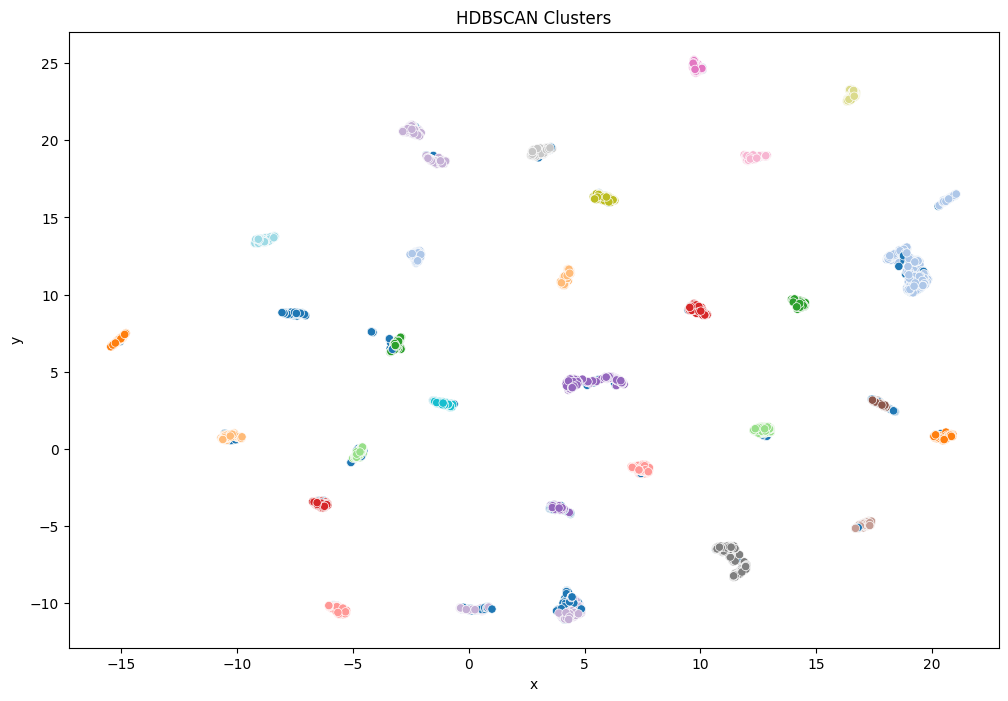

In [43]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x="x",
    y="y",
    hue="hdbscan",
    palette="tab20",
    legend=False
)

plt.title(
    "HDBSCAN Clusters"
)

plt.savefig(
    OUTPUT_DIR / "04_hdbscan.png",
    dpi=300,
    bbox_inches="tight"
)

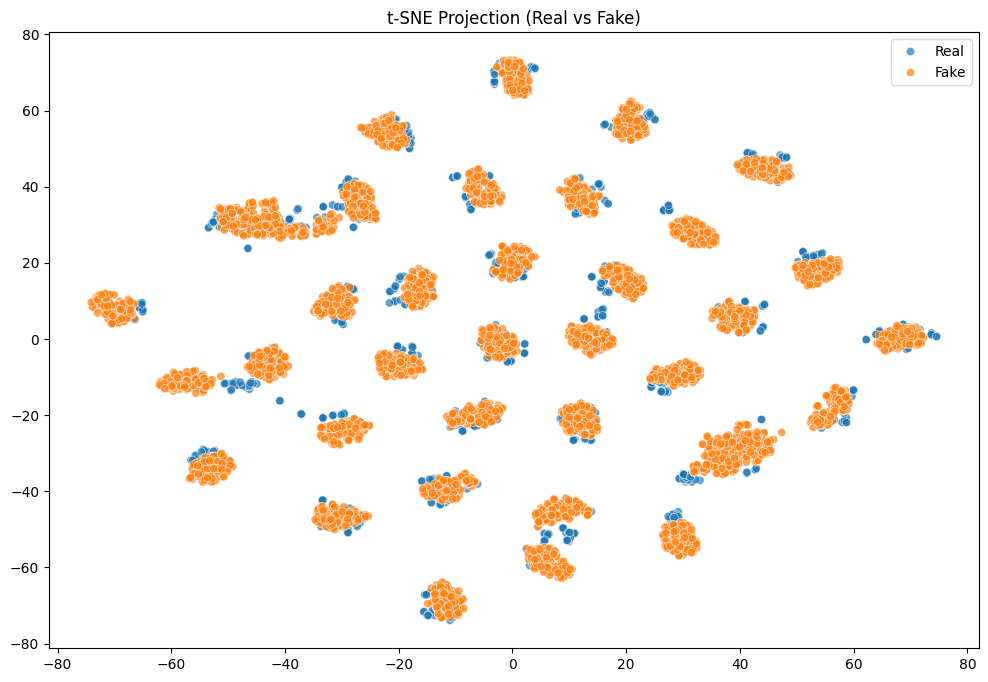

In [44]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

tsne_embedding = tsne.fit_transform(X_scaled)

plt.figure(figsize=(12,8))

sns.scatterplot(
    x=tsne_embedding[:,0],
    y=tsne_embedding[:,1],
    hue=domains,
    alpha=0.7
)

plt.title("t-SNE Projection (Real vs Fake)")

plt.savefig(
    OUTPUT_DIR / "06_tsne_real_fake.png",
    dpi=300
)